# EDA — 호텔 예약 취소 예측
> 데이터: `data/train.csv` (bookings_weather_pm, 시간 기반 split 후 train 셋)  
> 기간: 2015-07 ~ 2016-12 | 78,703행 × 38컬럼

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
CANCEL_PALETTE = ['#4C9BE8', '#E85C5C']  # 정상=파랑, 취소=빨강

df = pd.read_csv('../data/train.csv', parse_dates=['arrival_date'])
print(f'shape: {df.shape}')
df.head(3)

shape: (78703, 38)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,precipitation_sum,temperature_2m_max,temperature_2m_min,temperature_2m_mean,wind_speed_10m_max,wind_speed_10m_mean,precipitation_hours,rain_sum,relative_humidity_2m_mean,cloud_cover_mean
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,24.7,18.7,22.0,30.4,20.2,0.0,0.0,67,32
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,24.7,18.7,22.0,30.4,20.2,0.0,0.0,67,32
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0.0,24.7,18.7,22.0,30.4,20.2,0.0,0.0,67,32


---
## 1. 타겟 분포 — 취소율 전체 / 호텔 타입별

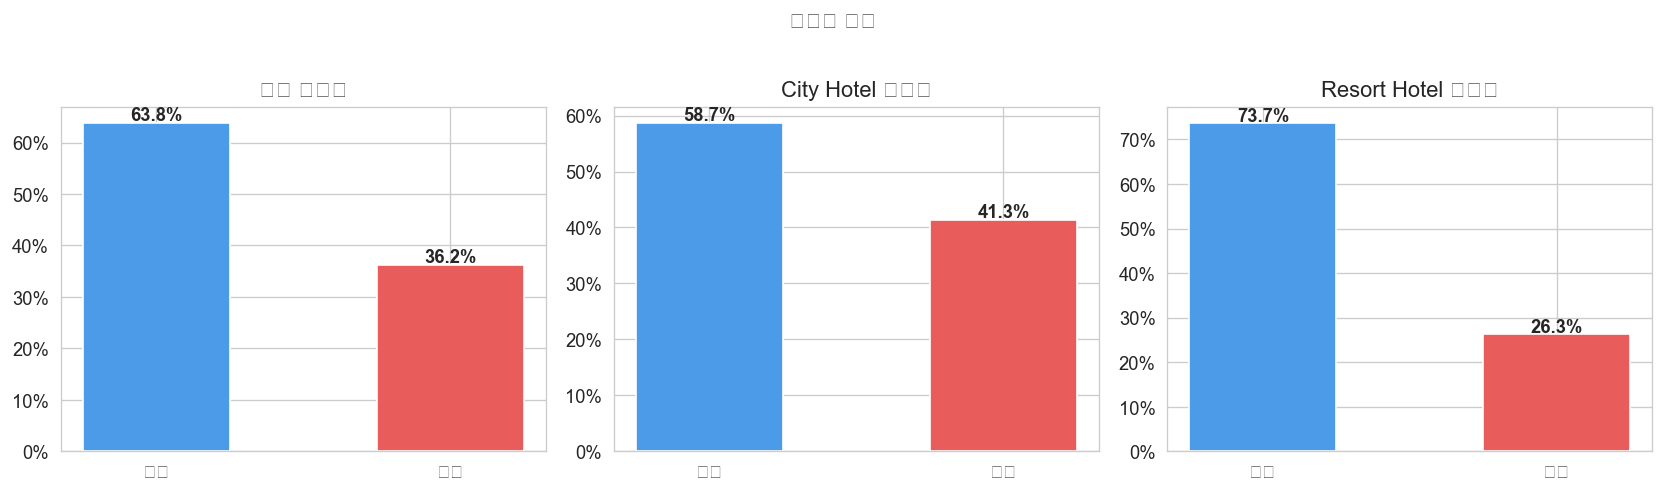

전체 취소율: 36.2%


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 전체
overall = df['is_canceled'].value_counts(normalize=True) * 100
axes[0].bar(['정상', '취소'], overall[[0, 1]], color=CANCEL_PALETTE, width=0.5)
axes[0].set_title('전체 취소율')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(overall[[0, 1]]):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# 호텔 타입별
for ax, hotel in zip(axes[1:], ['City Hotel', 'Resort Hotel']):
    rate = df[df['hotel'] == hotel]['is_canceled'].value_counts(normalize=True) * 100
    ax.bar(['정상', '취소'], rate[[0, 1]], color=CANCEL_PALETTE, width=0.5)
    ax.set_title(f'{hotel} 취소율')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    for i, v in enumerate(rate[[0, 1]]):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('취소율 분포', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"전체 취소율: {df['is_canceled'].mean()*100:.1f}%")

---
## 2. lead_time — 예약 ~ 도착 기간과 취소율

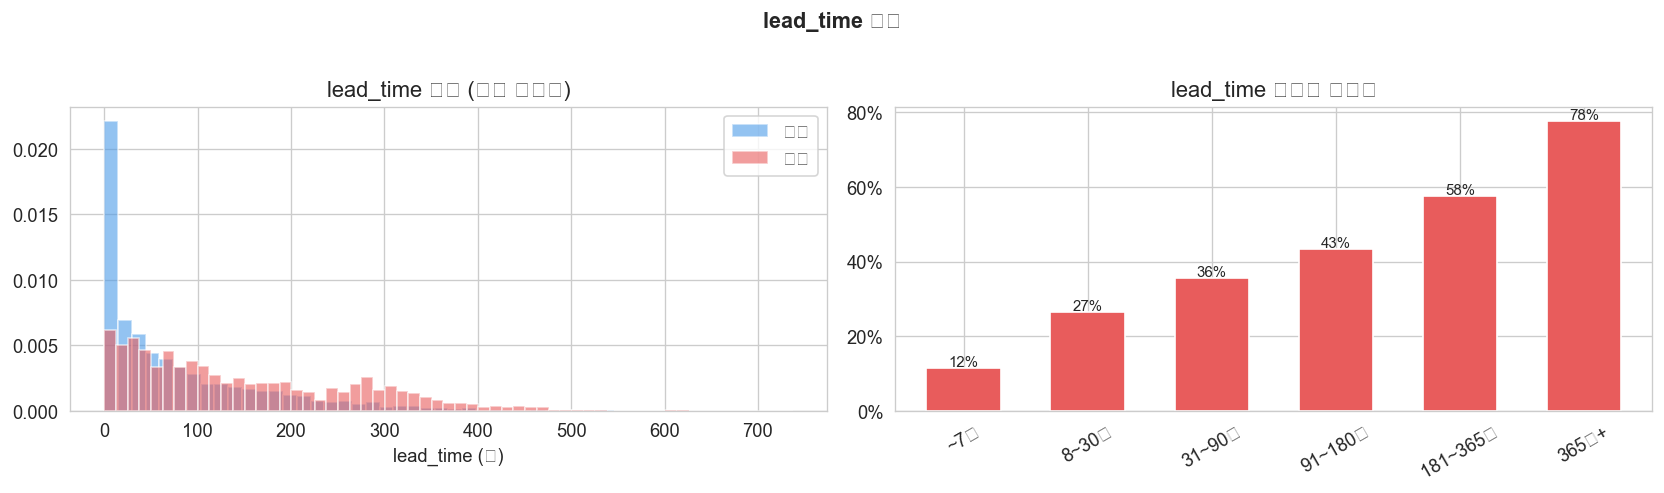

평균 lead_time — 정상: 75일  취소: 148일


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 취소 여부별 lead_time 분포
for label, color in zip([0, 1], CANCEL_PALETTE):
    axes[0].hist(df[df['is_canceled'] == label]['lead_time'],
                 bins=50, alpha=0.6, color=color,
                 label='정상' if label == 0 else '취소', density=True)
axes[0].set_xlabel('lead_time (일)')
axes[0].set_title('lead_time 분포 (취소 여부별)')
axes[0].legend()

# 구간별 취소율
bins = [0, 7, 30, 90, 180, 365, 999]
labels = ['~7일', '8~30일', '31~90일', '91~180일', '181~365일', '365일+']
df['lead_bin'] = pd.cut(df['lead_time'], bins=bins, labels=labels)
cancel_by_lead = df.groupby('lead_bin', observed=True)['is_canceled'].mean() * 100
cancel_by_lead.plot(kind='bar', ax=axes[1], color='#E85C5C', width=0.6, edgecolor='white')
axes[1].set_title('lead_time 구간별 취소율')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(cancel_by_lead):
    axes[1].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=9)

plt.suptitle('lead_time 분석', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"평균 lead_time — 정상: {df[df['is_canceled']==0]['lead_time'].mean():.0f}일  취소: {df[df['is_canceled']==1]['lead_time'].mean():.0f}일")

---
## 3. deposit_type × 취소율

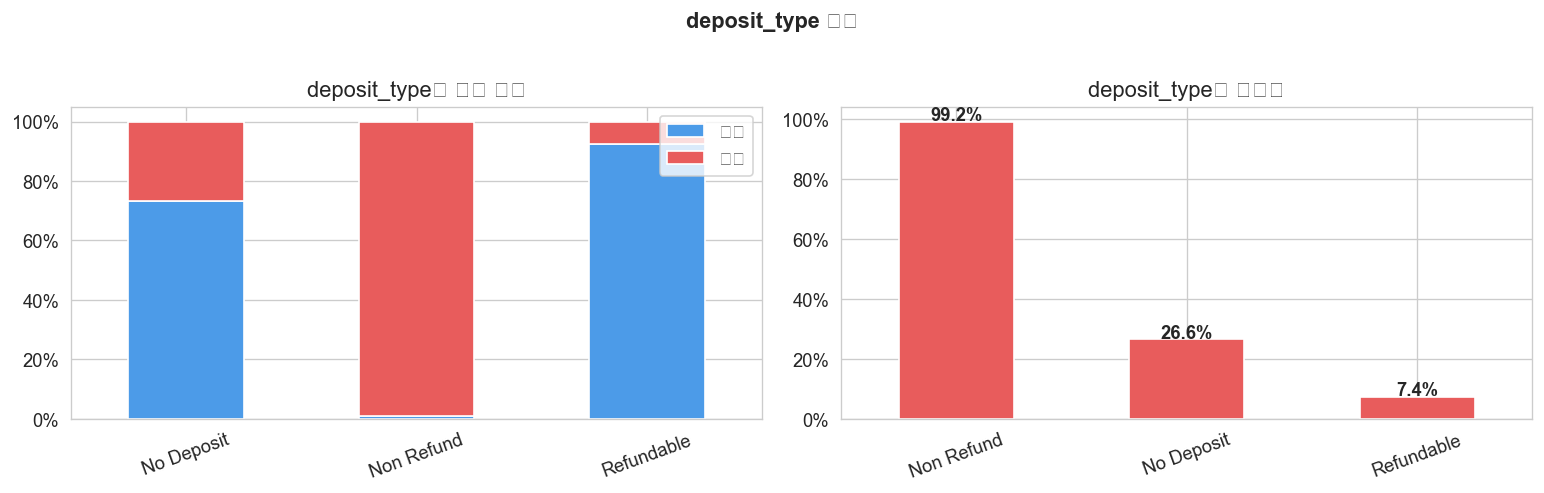

deposit_type
Non Refund    99.187458
No Deposit    26.565551
Refundable     7.407407
Name: is_canceled, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 비율 스택 바
deposit_ct = df.groupby('deposit_type')['is_canceled'].value_counts(normalize=True).unstack() * 100
deposit_ct[[0, 1]].rename(columns={0: '정상', 1: '취소'}).plot(
    kind='bar', stacked=True, ax=axes[0],
    color=CANCEL_PALETTE, edgecolor='white', width=0.5)
axes[0].set_title('deposit_type별 취소 비율')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(loc='upper right')

# 취소율만
cancel_rate = df.groupby('deposit_type')['is_canceled'].mean() * 100
cancel_rate.sort_values(ascending=False).plot(
    kind='bar', ax=axes[1], color='#E85C5C', width=0.5, edgecolor='white')
axes[1].set_title('deposit_type별 취소율')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(cancel_rate.sort_values(ascending=False)):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('deposit_type 분석', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(cancel_rate.sort_values(ascending=False))

---
## 4. previous_cancellations — 과거 취소 이력

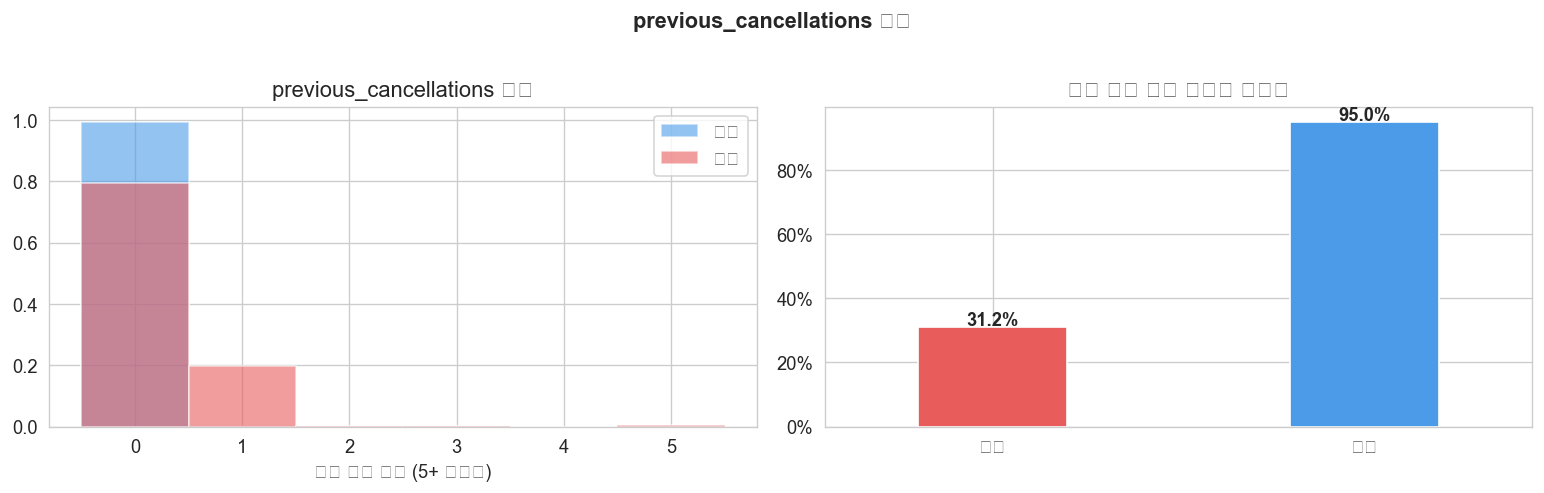

이전 취소 이력 있는 예약 비율: 7.9%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 분포 (0 / 1+ 구분)
has_prev = df['previous_cancellations'].clip(upper=3)
for label, color in zip([0, 1], CANCEL_PALETTE):
    axes[0].hist(df[df['is_canceled'] == label]['previous_cancellations'].clip(upper=5),
                 bins=range(7), alpha=0.6, color=color,
                 label='정상' if label == 0 else '취소', density=True, align='left')
axes[0].set_title('previous_cancellations 분포')
axes[0].set_xlabel('이전 취소 횟수 (5+ 클리핑)')
axes[0].legend()

# 이전 취소 유무별 취소율
df['has_prev_cancel'] = (df['previous_cancellations'] > 0).map({True: '있음', False: '없음'})
rate = df.groupby('has_prev_cancel')['is_canceled'].mean() * 100
rate.plot(kind='bar', ax=axes[1], color=['#E85C5C', '#4C9BE8'], width=0.4, edgecolor='white')
axes[1].set_title('이전 취소 이력 유무별 취소율')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(rate):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('previous_cancellations 분석', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"이전 취소 이력 있는 예약 비율: {(df['previous_cancellations']>0).mean()*100:.1f}%")

---
## 5. market_segment × 취소율

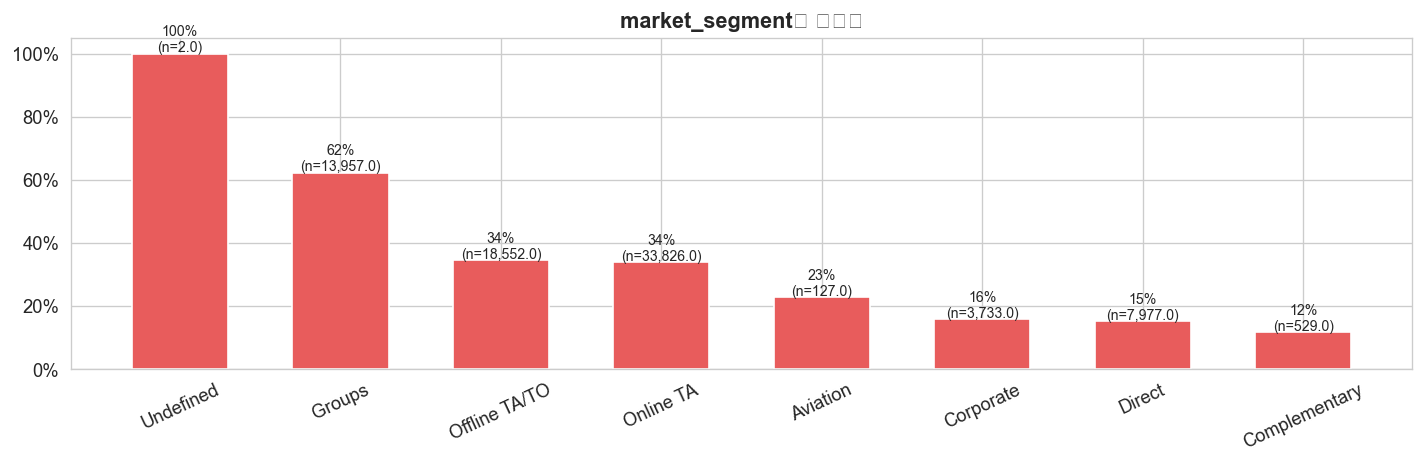

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))

seg = df.groupby('market_segment').agg(
    count=('is_canceled', 'count'),
    cancel_rate=('is_canceled', 'mean')
).sort_values('cancel_rate', ascending=False)
seg['cancel_rate'] *= 100

bars = ax.bar(seg.index, seg['cancel_rate'], color='#E85C5C', edgecolor='white', width=0.6)
ax.set_title('market_segment별 취소율', fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.tick_params(axis='x', rotation=25)

for bar, (_, row) in zip(bars, seg.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{row['cancel_rate']:.0f}%\n(n={row['count']:,})",
            ha='center', fontsize=8.5)

plt.tight_layout()
plt.show()

---
## 6. 날씨 변수 × 취소율 — 시간 비대칭성 검토

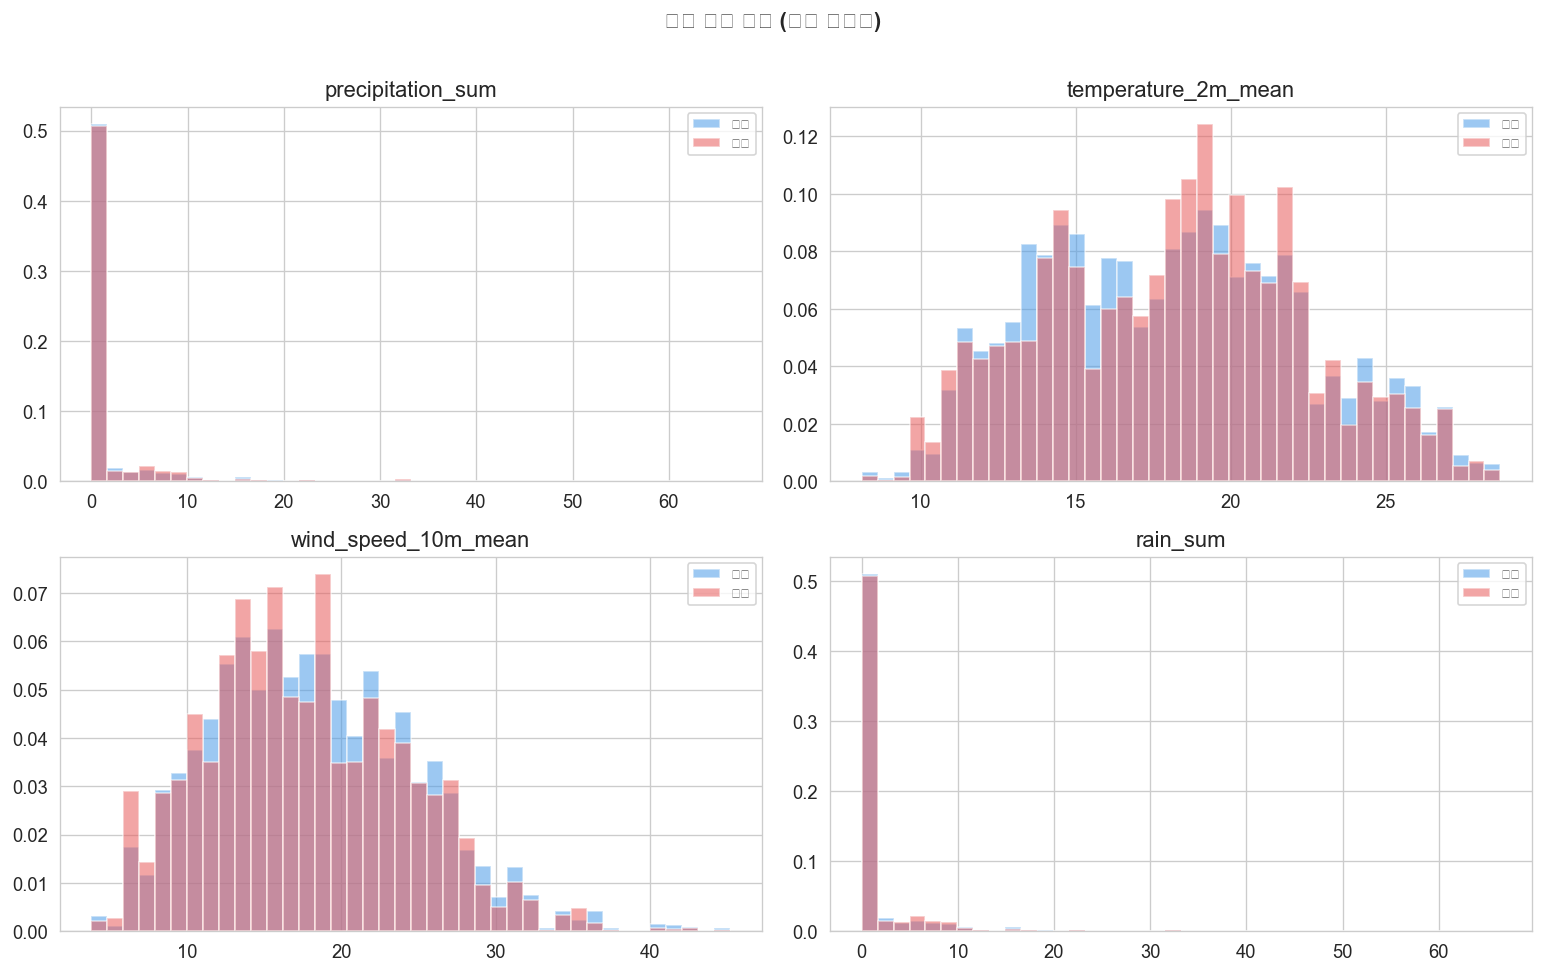

In [7]:
weather_cols = ['precipitation_sum', 'temperature_2m_mean', 'wind_speed_10m_mean', 'rain_sum']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for ax, col in zip(axes, weather_cols):
    for label, color in zip([0, 1], CANCEL_PALETTE):
        vals = df[df['is_canceled'] == label][col].dropna()
        ax.hist(vals, bins=40, alpha=0.55, color=color,
                label='정상' if label == 0 else '취소', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('날씨 변수 분포 (취소 여부별)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

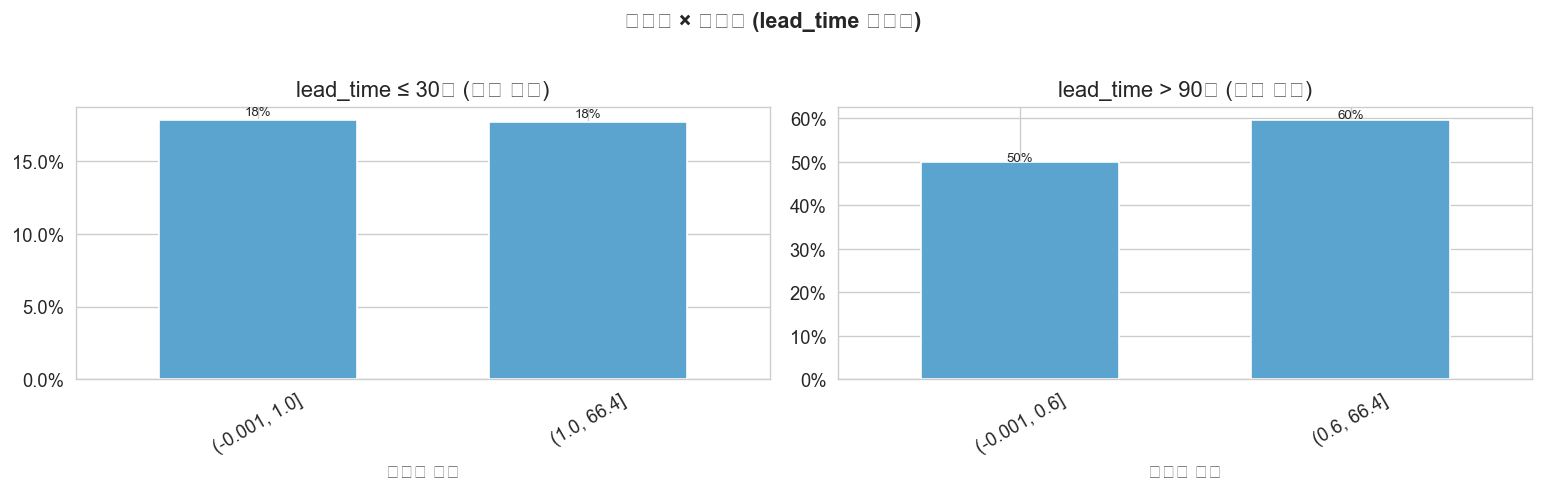

→ 슬라이드 7 시간 비대칭성 근거 그래프


In [8]:
# lead_time 구간별 precipitation_sum vs 취소율 (시간 비대칭성 핵심)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

short = df[df['lead_time'] <= 30]
long_ = df[df['lead_time'] > 90]

for ax, subset, title in zip(axes,
                              [short, long_],
                              ['lead_time ≤ 30일 (임박 예약)', 'lead_time > 90일 (장기 예약)']):
    bins = pd.qcut(subset['precipitation_sum'], q=5, duplicates='drop')
    rate = subset.groupby(bins, observed=True)['is_canceled'].mean() * 100
    rate.plot(kind='bar', ax=ax, color='#5BA4CF', edgecolor='white', width=0.6)
    ax.set_title(title)
    ax.set_xlabel('강수량 구간')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis='x', rotation=30)
    for i, v in enumerate(rate):
        ax.text(i, v + 0.3, f'{v:.0f}%', ha='center', fontsize=8)

plt.suptitle('강수량 × 취소율 (lead_time 구간별)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('→ 슬라이드 7 시간 비대칭성 근거 그래프')

---
## 7. 수치형 변수 상관관계 (취소 여부 포함)

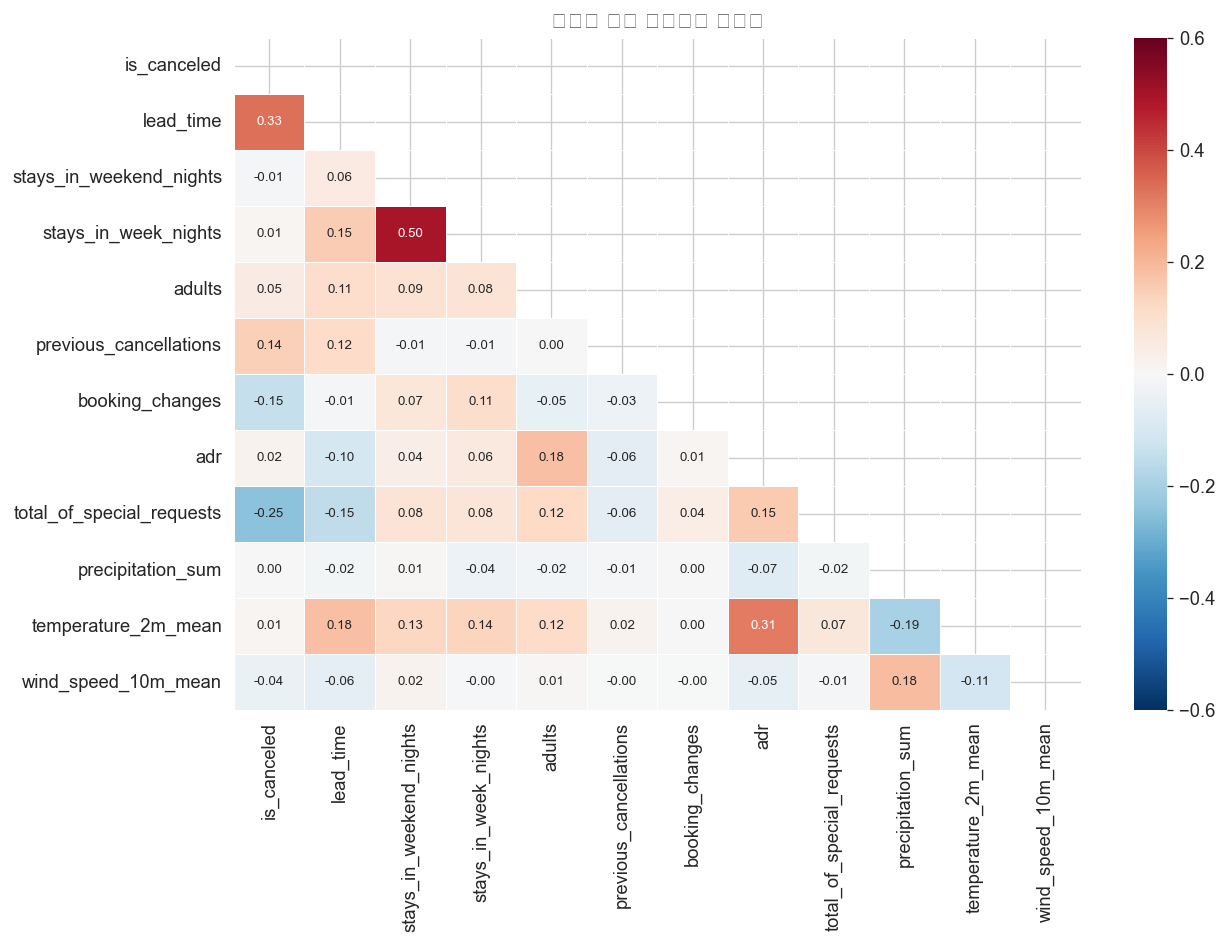

취소율과 상관 높은 변수 Top 5:
lead_time                    0.331491
total_of_special_requests    0.246773
booking_changes              0.145136
previous_cancellations       0.142553
adults                       0.050454
Name: is_canceled, dtype: float64


In [9]:
num_cols = ['is_canceled', 'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
            'adults', 'previous_cancellations', 'booking_changes',
            'adr', 'total_of_special_requests',
            'precipitation_sum', 'temperature_2m_mean', 'wind_speed_10m_mean']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.6, vmax=0.6, ax=ax,
            linewidths=0.4, annot_kws={'size': 8})
ax.set_title('수치형 변수 상관관계 히트맵', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# is_canceled와 상관이 높은 변수 top5
top_corr = corr['is_canceled'].drop('is_canceled').abs().sort_values(ascending=False)
print('취소율과 상관 높은 변수 Top 5:')
print(top_corr.head())

---
## 요약 — 발표 인사이트

| 분석 | 핵심 인사이트 |
|------|---------------|
| 취소율 | 전체 36%대, City Hotel이 Resort보다 ~14%p 높음 |
| lead_time | 취소 예약의 lead_time이 정상 예약보다 훨씬 길다 |
| deposit_type | Non Refund는 취소율 역설적으로 높음 (선결제 이미 포기) |
| previous_cancellations | 과거 취소 이력 있으면 취소율 급등 |
| market_segment | Online TA / Groups 취소율 높음 |
| 날씨 | 임박 예약(≤30일)에서만 날씨 영향 유의 — 시간 비대칭성 근거 |